# **Problem Statement**

You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

data

**Example lines from the above file:**

        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90838	91006	IH02_00.pairs@15152	168	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90846	90998	IH02_04.pairs@4163	152	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90851	91000	IH02_04.pairs@4164	149	+
        
From every line of this file, you have to derive three values:

X: Difference between two centers. C1 = center using Column3 and Column4, C2 = center using Column9 and Column10. X-coordinate will be C2 - C1

Y: Column10 - Column9

Z: Counter of Y at X. By default Z for Y at X is Zero.

And example is:

-500 65 10

X: -500, Y: 65, and Z: 10, telling that 500 bases relative to protein bound to DNA has 10 fragments of 65 base pair in size.

You have to plot a heatmap of this.

# **Approach**

---

### **Goal of the Task**

The goal is to **visualize a V-shaped pattern** of DNA fragment coverage around protein binding sites. When a protein binds to DNA, the nearby region becomes resistant to cleavage by nucleases, resulting in a specific fragment distribution pattern. By plotting the positions and lengths of these fragments relative to the center of the binding site, we can observe this protection effect in the form of a **V-plot**.

- **X-axis (X):** Distance of the fragment center from the binding site center.
- **Y-axis (Y):** Length of the DNA fragment.
- **Z-axis (Z):** Number of such fragments observed (i.e., count of Y at X).

A **heatmap** is used to display this data, where the color intensity represents the frequency (Z).

---

### **Input Data Format**

The input file (`mapped.bed`) is a tab-separated file with no header, where each line represents a mapped DNA fragment in relation to a protein binding region. Key columns:

- **Column 3 and 4**: Start and end of the protein binding site.
- **Column 9 and 10**: Start and end of the DNA fragment.

Example line:
 chr1	90919	91937	…	chr1	90838	91006	…

From this, we derive:
- **C1**: Center of binding site = (Column 3 + Column 4) // 2
- **C2**: Center of DNA fragment = (Column 9 + Column 10) // 2
- **X** = C2 - C1
- **Y** = Column 10 - Column 9
- **Z** = Count of how many times this (X, Y) combination appears

---

### **Step-by-Step Explanation of the Solution**

1. **Reading the BED File**  
   The BED file is read using `pandas.read_csv()` with `sep='\t'` and `header=None`, as the file does not contain column headers. This converts the data into a DataFrame for easier manipulation.

2. **Parsing Coordinates to Compute X and Y**  
   For each row:
   - Compute `C1` = midpoint of the binding site using Column 3 and Column 4.
   - Compute `C2` = midpoint of the fragment using Column 9 and Column 10.
   - Calculate **X** = C2 - C1 → This gives the fragment’s position relative to the binding site.
   - Calculate **Y** = Column 10 - Column 9 → This gives the fragment's length.

3. **Counting Occurrences (Z)**  
   Use a dictionary of dictionaries to record how many times each `(X, Y)` pair appears in the data. This builds a 2D histogram of fragment counts across different distances and lengths.

4. **Preparing the Heatmap Matrix**  
   - Convert the nested dictionary into a pandas DataFrame.
   - Transpose the matrix so that rows correspond to Y (fragment length) and columns correspond to X (relative position).
   - Fill any missing values with 0.
   - Sort both X and Y axes for better visualization.

5. **Plotting the V-Plot Heatmap**  
   - Use `seaborn.heatmap()` to plot the matrix.
   - The X-axis represents distance from the binding site center.
   - The Y-axis represents fragment length.
   - The color intensity shows the count (Z).
   - Invert the Y-axis so that shorter fragments are shown at the top (standard in biological visualizations).
   - Add axis labels and a plot title for clarity.

---

### **Conclusion**

This approach provides a biological visualization (V-plot) that helps identify regions protected by protein binding on DNA. The V-shape emerges naturally due to fragment distributions and cleavage patterns, and the heatmap visually encodes fragment counts across relative positions and lengths.


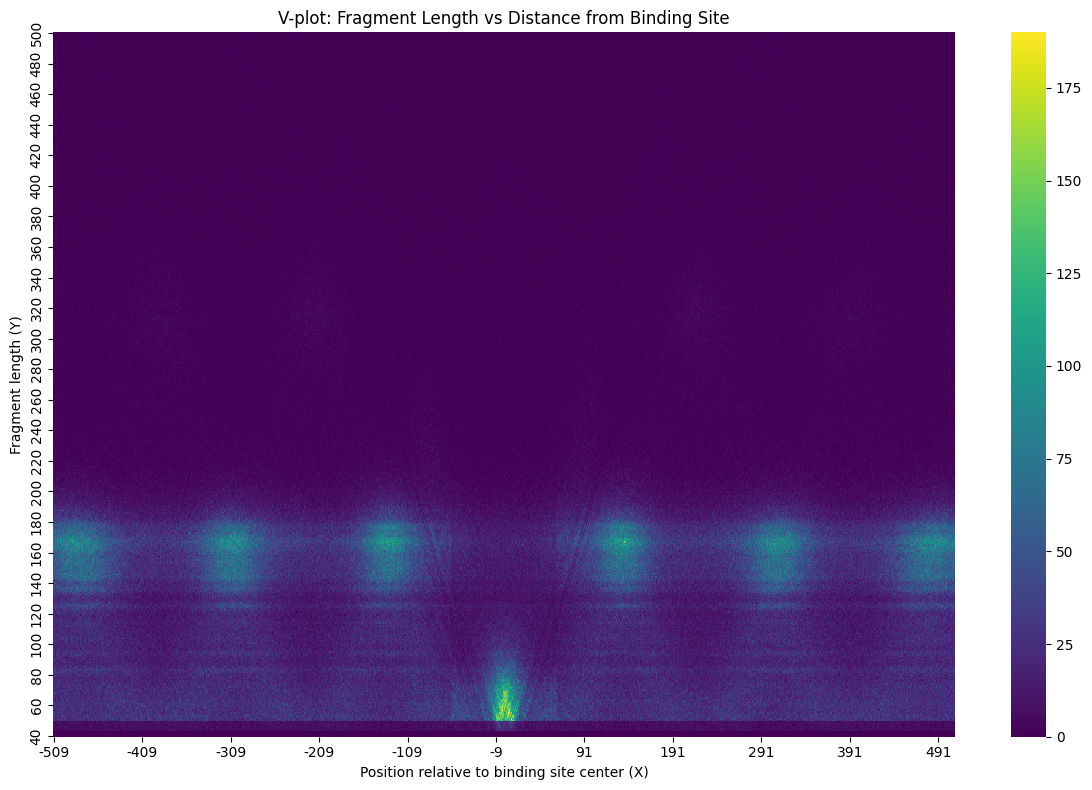

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Step 1: Load the BEDPE-like file (no header assumed)
file_path = "mapped.bed"  # Replace with your actual path
data = pd.read_csv(file_path, sep='\t', header=None)

# Step 2: Prepare a 2D histogram (dictionary of dictionaries)
# X = distance from binding site center
# Y = fragment length
heatmap_data = defaultdict(lambda: defaultdict(int))

for _, row in data.iterrows():
    # Binding site center (assumed midpoint of [2], [3])
    C1 = (row[2] + row[3]) // 2
    # Fragment center (assumed midpoint of [8], [9])
    C2 = (row[8] + row[9]) // 2
    X = C2 - C1  # Distance from binding site
    Y = row[9] - row[8]  # Fragment length

    # Increment count of this (Y, X) combination
    heatmap_data[Y][X] += 1

# Step 3: Convert to DataFrame for heatmap plotting
df_heat = pd.DataFrame(heatmap_data).T.fillna(0)

# Optional: Sort axes for cleaner heatmap structure
df_heat = df_heat.sort_index().sort_index(axis=1)

# Step 4: Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_heat, cmap="viridis", xticklabels=100, yticklabels=20)

# Flip Y-axis to make V shape (rather than inverted V)
plt.gca().invert_yaxis()

# Plot labels
plt.title("V-plot: Fragment Length vs Distance from Binding Site")
plt.xlabel("Position relative to binding site center (X)")
plt.ylabel("Fragment length (Y)")
plt.tight_layout()
plt.show()